<a href="https://colab.research.google.com/github/AngryRaccoon77/ASRService_assistent/blob/main/KAN_tinyshakespeare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/Blealtan/efficient-kan.git -q


In [1]:
# @title 1. Установка и Импорт

import torch
import torch.nn as nn
from torch.nn import functional as F
from efficient_kan import KAN
import textwrap
from torch.optim. lr_scheduler import LambdaLR
import math
from tqdm import tqdm, trange
# Проверка GPU (обязательно включи T4 в Runtime -> Change runtime type)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Working on device: {device}")

Working on device: cuda


In [2]:
# @title 2. Загрузка данных (TinyShakespeare)
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O input.txt

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Создаем словарь символов
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Разделение на Train/Val
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]

# Функция получения батча
def get_batch(split, block_size, batch_size):
    data_src = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_src) - block_size, (batch_size,))
    x = torch.stack([data_src[i:i+block_size] for i in ix])
    y = torch.stack([data_src[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

print(f"Vocab size: {vocab_size}")
print(f"Data length: {len(text)} chars")

--2025-11-28 16:09:51--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.006s  

2025-11-28 16:09:51 (192 MB/s) - ‘input.txt’ saved [1115394/1115394]

Vocab size: 65
Data length: 1115394 chars


In [3]:
# @title 3. Архитектура FractalKAN (Исправленная)
class FractalKANLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, layers_rnn, grid_size=5, spline_order=3):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)

        # KAN-Encoder
        self.kan_encoder = KAN([embed_dim, hidden_dim], grid_size=grid_size, spline_order=spline_order)

        # RNN Core
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=layers_rnn, batch_first=True)

        # KAN-Decoder
        self.kan_decoder = KAN([hidden_dim, vocab_size], grid_size=grid_size, spline_order=spline_order)

        self.dropout = nn.Dropout(0.1)

    def forward(self, idx, targets=None):
        # idx: [Batch, Time]

        # 1. Embeddings
        x = self.token_embedding(idx) # [B, T, Embed_Dim]

        # 2. KAN Projection
        B, T, C = x.shape
        # Используем reshape вместо view для безопасности
        x = x.reshape(-1, C)
        x = self.kan_encoder(x)
        x = F.relu(x)
        x = x.view(B, T, -1)

        # 3. RNN Pass
        x, _ = self.rnn(x) # [B, T, Hidden_Dim]
        x = self.dropout(x)

        # 4. KAN Decoding (Head)
        B, T, C = x.shape
        # ВОТ ТУТ БЫЛА ОШИБКА.
        # Добавляем .contiguous(), чтобы выровнять память после RNN
        x = x.contiguous().view(-1, C)

        logits = self.kan_decoder(x) # [B*T, Vocab_Size]
        logits = logits.view(B, T, -1) # [B, T, Vocab_Size]

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=0.8):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -256:]
            logits, _ = self. forward(idx_cond)
            logits = logits[:, -1, :] / temperature  # <-- вот это
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [4]:

def get_lr_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            # Линейный warmup от 0 до 1
            return step / warmup_steps
        else:
            # Cosine decay
            progress = (step - warmup_steps) / (total_steps - warmup_steps)
            return 0.5 * (1 + math.cos(math. pi * progress))

    return LambdaLR(optimizer, lr_lambda)

In [5]:


# Гиперпараметры (уровень Nano)
batch_size = 32
block_size = 256 # Длина контекста
max_iters = 3000 # Количество шагов обучения
eval_interval = 200
learning_rate = 5e-3  # Можно выше с warmup
warmup_steps = 200    # Первые 200 шагов — разгон
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Размеры модели
embed_dim = 512
hidden_dim = 1024 # RNN размер
rnn_layers = 3
kan_grid = 5 # Размер сетки сплайна (чем больше, тем точнее, но медленнее)

model = FractalKANLM(vocab_size, embed_dim, hidden_dim, rnn_layers, grid_size=kan_grid)
model = model.to(device)

print(f"Количество параметров: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = get_lr_scheduler(optimizer, warmup_steps, max_iters)

# Списки для сохранения метрик
train_losses = []
val_losses = []

# Цикл обучения
for iter_num in trange(max_iters, desc="Обучение модели"):

    # Оценка потерь каждые N шагов
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        losses = {}
        model.eval()
        for split in ['train', 'val']:
            losses[split] = torch.zeros(50) # усредняем по 50 батчам
            for k in range(50):
                X, Y = get_batch(split, block_size, batch_size)
                logits, loss = model(X, Y)
                losses[split][k] = loss.item()
            losses[split] = losses[split].mean()
        model.train()
        tqdm.write(f"Step {iter_num}: Train Loss {losses['train']:.4f}, Val Loss {losses['val']:.4f}")
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())

    # Тренировочный шаг
    xb, yb = get_batch('train', block_size, batch_size)
    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    # После loss.backward(), перед optimizer.step():
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()


print("Обучение завершено!")

Количество параметров: 24.83 M


Обучение модели:   0%|          | 0/3000 [00:23<?, ?it/s]

Step 0: Train Loss 4.1764, Val Loss 4.1762


Обучение модели:   7%|▋         | 201/3000 [03:05<5:55:19,  7.62s/it]

Step 200: Train Loss 1.9856, Val Loss 2.0677


...

Step 2600: Train Loss 1.1888, Val Loss 1.5268


Обучение модели:  93%|█████████▎| 2801/3000 [37:26<25:20,  7.64s/it]

Step 2800: Train Loss 1.1732, Val Loss 1.5109


Обучение модели: 100%|██████████| 3000/3000 [40:04<00:00,  1.25it/s]

Step 2999: Train Loss 1.1678, Val Loss 1.5192
Обучение завершено!


In [8]:
# @title 5. Генерация Текста
context = torch.zeros((1, 1), dtype=torch.long, device=device) # Начинаем с нулевого токена
print("Генерация...")
generated_ids = model.generate(context, max_new_tokens=500)
print("--- РЕЗУЛЬТАТ ---")
print(decode(generated_ids[0].tolist()))

Генерация...
--- РЕЗУЛЬТАТ ---


ISABELLA:
The tears priest the will teeth a man would read,
His brother's soken and his flower than the Duke of his famous by the tear
of breathe the crown the poor proceedings of earnest, for I could have here
You know her sick of the ancient sword:
There didst awake my death, and that gives me renowned.

Second Citizen:
Withdraw my branches here, the gods,
And see the bover in people,--

MONTAGUE:
I the trumpets no lay.

ESCALUS:
Plack, I protest, and call thee speaks not the news: how for th


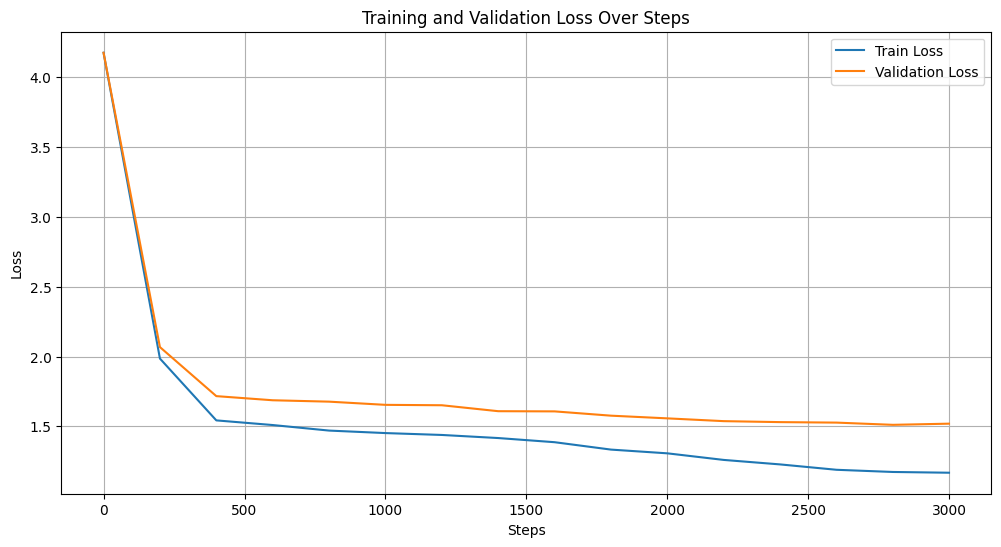

In [9]:
import matplotlib.pyplot as plt


def plot_losses(train_losses, val_losses, eval_interval, max_iters):
    plt.figure(figsize=(12, 6))
    steps = [i * eval_interval for i in range(len(train_losses) -1 )] + [max_iters -1]
    plt.plot(steps, train_losses, label='Train Loss')
    plt.plot(steps, val_losses, label='Validation Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title(textwrap.fill('Training and Validation Loss Over Steps', width=60))
    plt.legend()
    plt.grid(True)
    plt.show()

plot_losses(train_losses, val_losses, eval_interval, max_iters)
